In [52]:
import numpy as np
import struct
import os
import pickle

def load_mnist(path, kind='train'):
    labels_path = os.path.join(path, f'{kind}-labels.idx1-ubyte')
    images_path = os.path.join(path, f'{kind}-images.idx3-ubyte')
    
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', lbpath.read(8))
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack('>IIII', imgpath.read(16))
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)

    return images, labels

class Layer:
    def __init__(self, input_dim, output_dim):
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2.0/input_dim)
        self.bias = np.zeros((1, output_dim))
    
    def forward(self, x):
        self.input = x
        return np.dot(x, self.weights) + self.bias
    
    def backward(self, grad):
        self.w_grad = np.dot(self.input.T, grad)
        self.b_grad = np.sum(grad, axis=0, keepdims=True)
        return np.dot(grad, self.weights.T)
    
    def update(self, learning_rate):
        self.weights -= learning_rate * self.w_grad
        self.bias -= learning_rate * self.b_grad

class ReLU:
    def forward(self, x):
        self.input = x
        return np.maximum(0, x)
    
    def backward(self, grad):
        return grad * (self.input > 0)
    
    def update(self, learning_rate):
        pass
class Sigmoid:
    def forward(self, x):
        self.input = x
        return 1 / (1 + np.exp(-x))
    
    def backward(self, grad):
        sigmoid_output = self.forward(self.input)
        return grad * sigmoid_output * (1 - sigmoid_output)
    
    def update(self, learning_rate):
        pass

class Sigmoid:
    def forward(self, x):
        self.input = x
        return 1 / (1 + np.exp(-x))
    
    def backward(self, grad):
        sigmoid_output = self.forward(self.input)
        return grad * sigmoid_output * (1 - sigmoid_output)
    
    def update(self, learning_rate):
        pass

class Tanh:
    def forward(self, x):
        self.input = x
        return np.tanh(x)
    
    def backward(self, grad):
        tanh_output = self.forward(self.input)
        return grad * (1 - tanh_output ** 2)
    
    def update(self, learning_rate):
        pass

class LeakyReLU:
    def __init__(self, alpha=0.01):
        self.alpha = alpha

    def forward(self, x):
        self.input = x
        return np.where(x > 0, x, self.alpha * x)

    def backward(self, grad):
        return grad * np.where(self.input > 0, 1, self.alpha)

    def update(self, learning_rate):
        pass

class Softmax:
    def forward(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def backward(self, grad):
        return grad

    def update(self, learning_rate):
        pass

class CrossEntropyLoss:
    def forward(self, pred, target):
        self.pred, self.target = pred, target
        return -np.sum(target * np.log(pred + 1e-7)) / pred.shape[0]
    
    def backward(self):
        return (self.pred - self.target) / self.pred.shape[0]

class Dropout:
    def __init__(self, drop_prob=0.5):
        self.drop_prob = drop_prob
        self.mask = None
        self.training = True

    def forward(self, x):
        if self.training:
            self.mask = (np.random.rand(*x.shape) > self.drop_prob).astype(np.float32)
            return x * self.mask / (1.0 - self.drop_prob)
        else:
            return x

    def backward(self, grad):
        if self.training:
            return grad * self.mask / (1.0 - self.drop_prob)
        else:
            return grad

    def update(self, learning_rate):
        pass  # No parameters to update

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

class NeuralNetwork:
    def __init__(self, layers=None):
        if layers is None:
            layers = [
                Layer(784, 1024), Tanh(), 
                Layer(1024, 512), Tanh(), 
                Layer(512, 256), Tanh(),
                Layer(256, 10), Softmax()
            ]
        self.layers = layers
        self.loss_fn = CrossEntropyLoss()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)
    
    def update(self, learning_rate):
        for layer in self.layers:
            layer.update(learning_rate)
    
    def train_step(self, x, y, learning_rate):
        pred = self.forward(x)
        loss = self.loss_fn.forward(pred, y)
        self.backward(self.loss_fn.backward())
        self.update(learning_rate)
        return loss
    
    def predict(self, x):
        return np.argmax(self.forward(x), axis=1)
    
    def evaluate(self, x, y):
        for layer in self.layers:
            if isinstance(layer, Dropout):
                layer.eval() 
        return np.mean(self.predict(x) == y)
    
    def save_model(self, file_path):
        model_data = {
            'layers': [(layer.weights.copy(), layer.bias.copy()) if hasattr(layer, 'weights') else None 
                        for layer in self.layers]
        }
        with open(file_path, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"save model to: {file_path}")
    
    def load_model(self, file_path):
        with open(file_path, 'rb') as f:
            model_data = pickle.load(f)
        
        for i, layer_data in enumerate(model_data['layers']):
            if layer_data is not None and hasattr(self.layers[i], 'weights'):
                self.layers[i].weights = layer_data[0].copy()
                self.layers[i].bias = layer_data[1].copy()
        print(f"load model from: {file_path}")    
        
X_train, y_train = load_mnist('/home/featurize/work/AI2025/BP/train_data', kind='train')
X_test, y_test = load_mnist('/home/featurize/work/AI2025/BP/train_data', kind='t10k')
X_train, X_test = X_train.astype(np.float32) / 255.0, X_test.astype(np.float32) / 255.0

val_split = 0.2
n_val = int(X_train.shape[0] * val_split)
indices = np.random.permutation(X_train.shape[0])
X_val, y_val = X_train[indices[:n_val]], y_train[indices[:n_val]]
X_train, y_train = X_train[indices[n_val:]], y_train[indices[n_val:]]

y_train_onehot = np.eye(10)[y_train]
y_val_onehot = np.eye(10)[y_val]

In [ ]:

# 超参数网格搜索
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 64, 128, 256]
init_methods = ['he', 'xavier', 'standard']

best_val_acc = 0
best_params = {}

# for lr in learning_rates:
#     for bs in batch_sizes:
#         for init in init_methods:
#             print(f'\nTesting lr={lr}, batch_size={bs}, init={init}')
            
#             # 初始化模型
#             network = NeuralNetwork(init_method=init)
#             n_batches = X_train.shape[0] // bs
            
#             # 训练5个epoch来快速评估参数组合
#             for epoch in range(10):
#                 total_loss = 0
#                 for i in range(n_batches):
#                     batch_x = X_train[i * bs:(i + 1) * bs]
#                     batch_y = y_train_onehot[i * bs:(i + 1) * bs]
#                     total_loss += network.train_step(batch_x, batch_y, lr)
                
#                 val_acc = network.evaluate(X_val, y_val)
#                 print(f'Epoch {epoch + 1}: Loss {total_loss/n_batches:.4f}, Val Acc {val_acc:.4f}')
                
#                 if val_acc > best_val_acc:
#                     best_val_acc = val_acc
#                     best_params = {
#                         'learning_rate': lr,
#                         'batch_size': bs,
#                         'init_method': init
#                     }

# print('\nBest parameters found:')
# print(f'Learning rate: {best_params["learning_rate"]}')
# print(f'Batch size: {best_params["batch_size"]}')
# print(f'Init method: {best_params["init_method"]}')
# print(f'Best validation accuracy: {best_val_acc:.4f}')

best_params['learning_rate'] = 0.01  # 确保学习率在合理范围内
best_params['init_method'] = 'he'  # 确保初始化方法有效
best_params['batch_size'] = 32  # 确保batch_size不超过训练集大小
# 使用最佳参数训练最终模型
network = NeuralNetwork(init_method=best_params['init_method'])
batch_size = best_params['batch_size']
learning_rate = best_params['learning_rate']
epochs = 100
n_batches = X_train.shape[0] // batch_size

patience, best_loss, patience_counter = 5, float('inf'), 0
best_model = None
model_path = 'mnist_model.pkl'

# 使用原有的训练循环
for epoch in range(epochs):
    total_loss = 0
    for i in range(n_batches):
        batch_x = X_train[i * batch_size:(i + 1) * batch_size]
        batch_y = y_train_onehot[i * batch_size:(i + 1) * batch_size]
        total_loss += network.train_step(batch_x, batch_y, learning_rate)
    
    train_acc = network.evaluate(X_train, y_train)
    val_acc = network.evaluate(X_val, y_val)
    val_loss = network.loss_fn.forward(network.forward(X_val), y_val_onehot)
    
    print(f'Epoch {epoch + 1}: Loss {total_loss/n_batches:.4f}, Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}')
    
    if val_loss < best_loss:
        best_loss, patience_counter = val_loss, 0
        best_model = network
        network.save_model(model_path)
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print('Early stopping triggered.')
        break

test_acc = best_model.evaluate(X_test, y_test)
print(f'Final Test Accuracy: {test_acc:.4f}')

Epoch 1: Loss 0.4556, Train Acc 0.9304, Val Acc 0.9256
save model to: mnist_model.pkl
Epoch 2: Loss 0.2155, Train Acc 0.9507, Val Acc 0.9463
save model to: mnist_model.pkl


KeyboardInterrupt: 

## 直接加载模型

In [ ]:
network = NeuralNetwork()
model_path = 'mnist_model_98.pkl'
network.load_model(model_path)
test_acc = network.evaluate(X_test, y_test)
print('test_acc:', test_acc)

FileNotFoundError: [Errno 2] No such file or directory: 'mnist_model.pkl'

## Train from Scratch

Epoch 1: Loss 0.3441, Train Acc 0.9366, Val Acc 0.9338
save model to: mnist_model.pkl
Epoch 2: Loss 0.1845, Train Acc 0.9561, Val Acc 0.9525
save model to: mnist_model.pkl
Epoch 3: Loss 0.1365, Train Acc 0.9672, Val Acc 0.9602
save model to: mnist_model.pkl
Epoch 4: Loss 0.1076, Train Acc 0.9735, Val Acc 0.9651
save model to: mnist_model.pkl
Epoch 5: Loss 0.0876, Train Acc 0.9784, Val Acc 0.9679
save model to: mnist_model.pkl
Epoch 6: Loss 0.0727, Train Acc 0.9825, Val Acc 0.9702
save model to: mnist_model.pkl
Epoch 7: Loss 0.0611, Train Acc 0.9855, Val Acc 0.9712
save model to: mnist_model.pkl
Epoch 8: Loss 0.0517, Train Acc 0.9884, Val Acc 0.9729
save model to: mnist_model.pkl
Epoch 9: Loss 0.0440, Train Acc 0.9903, Val Acc 0.9738
save model to: mnist_model.pkl
Epoch 10: Loss 0.0377, Train Acc 0.9921, Val Acc 0.9747
save model to: mnist_model.pkl
Epoch 11: Loss 0.0324, Train Acc 0.9935, Val Acc 0.9757
save model to: mnist_model.pkl
Epoch 12: Loss 0.0279, Train Acc 0.9947, Val Acc 0.9

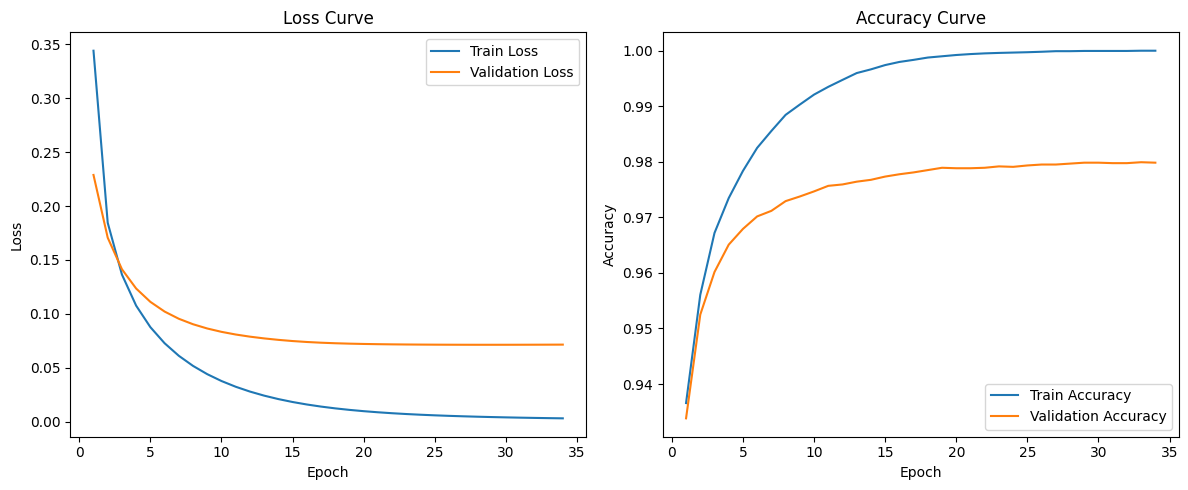

In [53]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy values
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Assuming these variables are already defined in your script
batch_size, epochs, learning_rate = 128, 200, 0.1
n_batches = X_train.shape[0] // batch_size
patience, best_loss, patience_counter = 5, float('inf'), 0
best_model = None
model_path = 'mnist_model.pkl'
network = NeuralNetwork()
# Start of your training loop
for epoch in range(epochs):
    total_loss = 0
    for i in range(n_batches):
        batch_x = X_train[i * batch_size:(i + 1) * batch_size]
        batch_y = y_train_onehot[i * batch_size:(i + 1) * batch_size]
        total_loss += network.train_step(batch_x, batch_y, learning_rate)
    
    train_acc = network.evaluate(X_train, y_train)
    val_acc = network.evaluate(X_val, y_val)
    val_loss = network.loss_fn.forward(network.forward(X_val), y_val_onehot)
    
    # Record losses and accuracies
    train_losses.append(total_loss / n_batches)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f'Epoch {epoch + 1}: Loss {total_loss / n_batches:.4f}, Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}')
    
    if val_loss < best_loss:
        best_loss, patience_counter = val_loss, 0
        best_model = network
        network.save_model(model_path)
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# After training, plot the loss and accuracy curves

test_acc = best_model.evaluate(X_test, y_test)
print(f'Final Test Accuracy: {test_acc:.4f}')
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()